<div align='center'>

# **Práctica 1 — Minería de Textos y Análisis de Sentimientos**

**Máster Universitario en Inteligencia Artificial**  
**Asignatura:** Minería de Textos y Modelos de Lenguaje

<br/>
Autores:
- Cristian Rubio Barato — <a href='mailto:Cristian.Rubio@alu.uclm.es'>Cristian.Rubio@alu.uclm.es</a>  
- José Lara Navarro — <a href='mailto:Jose.Lara3@alu.uclm.es'>Jose.Lara3@alu.uclm.es</a>

</div>

<a id='indice'></a>

**Índice**

- [1. Carga y preparación inicial del conjunto de datos](#sec1)
- [2. Preprocesado y limpieza del texto](#sec2)
- [3. Vectorización del corpus](#sec3)
  - [3.1. Exploración de parámetros de vectorización](#sec3_1)
  - [3.2. Vectorización final con BoW y TF-IDF](#sec3_2)
- [4. Entrenamiento y evaluación de modelos mediante retención (80/20)](#sec4)
  - [4.1. Partición estratificada del conjunto de datos](#sec4_1)
  - [4.2. Entrenamiento de los tres modelos](#sec4_2)
  - [4.3. Evaluación gráfica: matrices de confusión y curvas ROC](#sec4_3)
  - [4.4. Tabla comparativa de resultados (retención)](#sec4_4)
- [5. Evaluación mediante validación cruzada](#sec5)
  - [5.1. Definición del esquema de validación cruzada](#sec5_1)
  - [5.2. Entrenamiento y evaluación por folds](#sec5_2)
  - [5.3. Presentación de resultados agregados](#sec5_3)
    - [5.3.1. Matrices de confusión acumuladas](#sec5_3_1)
    - [5.3.2. Curvas ROC acumuladas](#sec5_3_2)
    - [5.3.3. Tabla resumen con media y desviación típica](#sec5_3_3)
- [6. Discusión y análisis de resultados](#sec6)
  - [6.1. Representación del texto y número de términos](#sec6_1)
  - [6.2. Mejor resultado obtenido y comportamiento del modelo](#sec6_2)
  - [6.3. Estabilidad y límite del rendimiento](#sec6_3)
- [7. Bonus Track: Interpretabilidad del modelo mediante LIME](#sec7)
  - [7.1. Selección de instancias para explicar](#sec7_1)
  - [7.2. Explicaciones LIME](#sec7_2)
  - [7.3. Análisis crítico de las explicaciones LIME](#sec7_3)
- [8. Declaración de uso responsable de Inteligencia Artificial](#sec8)

<a id='sec1'></a>
## 1. Carga y preparación inicial del conjunto de datos

El dataset contiene 2590 tweets etiquetados con polaridad (positivo o negativo). Separamos el texto (corpus) y la variable objetivo (polaridad), codificándola de forma numérica para poder trabajar con modelos de clasificación supervisada.

In [1]:
import pandas as pd
import numpy as np
from preprocesado import limpiar_texto, lematizar_por_lotes, vectorizar_bow, vectorizar_tfidf

df = pd.read_csv('sentiment_analysis_dataset_polarity.csv')
print(f"Dimensiones del dataset: {df.shape}")

corpus = df['text']
target = df['polarity'].map({'negativo': 0, 'positivo': 1})

print(f"Número de documentos en el corpus: {len(corpus)}")
print(f"\nDistribución de clases:")
print(target.value_counts().rename({0: 'negativo (0)', 1: 'positivo (1)'})) # Para mostrar las etiquetas de forma más clara
print(f"\nProporción positivos: {target.mean():.2%}")
print(f"Proporción negativos: {(1 - target.mean()):.2%}")

Dimensiones del dataset: (2590, 6)
Número de documentos en el corpus: 2590

Distribución de clases:
polarity
positivo (1)    1430
negativo (0)    1160
Name: count, dtype: int64

Proporción positivos: 55.21%
Proporción negativos: 44.79%


<a id='sec2'></a>
## 2. Preprocesado y limpieza del texto

Aplicamos el pipeline de preprocesado visto en clase: conversión a minúsculas, eliminación de caracteres especiales y normalización de espacios, seguido de lematización con SpaCy. Esto reduce la variabilidad del vocabulario y facilita la vectorización posterior.

Conviene señalar que, en análisis de sentimientos, la eliminación indiscriminada de *stopwords* puede ser contraproducente, ya que palabras como "no" o "muy" modulan el sentimiento. El pipeline de preprocesado.py ya filtra *stopwords* en la lematización, incluyendo estos adverbios de negación. Hemos probado tres alternativas para evaluar el impacto de esta decisión:

1. **Alternativa 1: Eliminar todas las *stopwords*** (versión original de preprocesado.py). Es la que usamos en clase y la que mejores resultados nos da.
2. **Alternativa 2: Conservar todas las *stopwords*.** Los resultados empeoran notablemente (entre 3 y 6 puntos de accuracy en validacion cruzada). El motivo es claro: los términos más frecuentes pasan a ser "el", "de", "que", "ser", "en", que no tienen carga sentimental y desplazan del vocabulario (limitado a 5000 features) a términos realmente discriminativos como "sentir", "querer" o "frustrado". En LIME, el modelo empieza a usar artículos y verbos copulativos como términos influyentes, lo cual no tiene sentido semántico.
3. **Alternativa 3: Eliminar stopwords pero conservar adverbios de negación** ("no", "nunca", "tampoco"), usando el atributo morfológico de SpaCy `"Neg" in t.morph.get("Polarity")`. Los resultados son ligeramente peores que la versión original (diferencias de entre 0.001 y 0.004 en accuracy), y en LIME "no" no aparece como término influyente en ninguna de las instancias analizadas.

Esto último tiene una explicación clara: **en representaciones como BoW o TF-IDF, cada término es una dimensión independiente sin conexión con las palabras adyacentes**. "No" aparece como un término aislado, de modo que el modelo no puede distinguir entre un "no" que niega algo negativo ("no estoy triste") y uno que niega algo positivo ("no estoy contento"). Al no poder capturar esa relación, "no" acaba siendo una feature sin capacidad discriminativa que simplemente ocupa espacio en el vocabulario. Por eso eliminarlo no perjudica, e incluso mejora marginalmente los resultados.

**Nos quedamos con la version original** (alternativa 1) que elimina todas las *stopwords*, ya que es la que mejor rendimiento ofrece y la explicacion de por que funciona mejor es coherente con las limitaciones de las representaciones BoW y TF-IDF.

In [2]:
corpus_limpio = corpus.apply(limpiar_texto)

# Lematizamos por lotes para mejorar eficiencia
lemas = lematizar_por_lotes(corpus_limpio)

print("Ejemplo de texto limpio vs. lematizado:\n")
for i in [0, 5, 10]:
    print(f"  Limpio      : {corpus_limpio.iloc[i]}")
    print(f"  Lematizado  : {lemas.iloc[i]}")
    print()
    
print("Lemas:")
lemas


Ejemplo de texto limpio vs. lematizado:

  Limpio      : termine bien abrumado después de hoy
  Lematizado  : terminar abrumado

  Limpio      : estoy abrumado de airdrops de youtube y de todo es imposible gestionarlo todo todo se mueve muy rápido o determino un plan o me quemo
  Lematizado  : abrumado airdrops youtube imposible gestionar él mover rápido determinar plan quemar

  Limpio      : y entonces aprendimos que si está desbordado y ni él se aguanta es por dos razones hambre o sueño hoy resultó ser la segunda y ya hijo dormido a las 8 p m
  Lematizado  : aprender desbordado aguantar razón hambre sueño resultar hijo dormido 8 p m

Lemas:


0                                       terminar abrumado
1                                         sentir abrumado
2       sentir abrumado cantidad cosa querer dibujar j...
3       salvador único persona abrumar versión nadieco...
4                          denmir helado ar full abrumado
                              ...                        
2585    vivir miedo manejen borrachos dejar cinturón s...
2586                           vida constante miedo éxito
2587    esquizofrenia mente dividido miedo realidad pa...
2588                    miedo desaparez mundo temer mundo
2589         saltar apoco ala pile agua xd miedo relajado
Name: text, Length: 2590, dtype: str

Podemos ver, como decíamos antes, que hemos perdido algunos matices al eliminar *stopwords*, pero el texto resultante es más limpio y manejable para los modelos de clasificación.

<a id='sec3'></a>
## 3. Vectorización del corpus

Transformamos los textos lematizados en representaciones numéricas. Trabajamos con dos técnicas: Bag of Words (BoW), que se basa en el conteo de frecuencias, y TF-IDF, que pondera cada término según su relevancia relativa dentro del corpus.

Antes de fijar los parámetros finales, **exploramos distintas configuraciones de n-gramas, min_df y max_features** para entender cómo afectan al tamaño del vocabulario y a la calidad de la representación.

<a id='sec3_1'></a>
### 3.1. Exploración de parámetros de vectorización

Probamos varias combinaciones para ver cómo cambia el número de términos resultante. El objetivo es encontrar un equilibrio: un vocabulario demasiado grande introduce ruido y esparsidad, mientras que uno demasiado reducido pierde información discriminativa.

En nuestras configuraciones también limitamos por `max_features` para evitar un vocabulario excesivamente grande que pueda hacer que el modelo se ahogue con miles de columnas que son puro ruido.

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

configuraciones = [
    {"ngram_range": (1, 1), "min_df": 2,    "max_df": 0.95, "max_features": None},
    {"ngram_range": (1, 2), "min_df": 2,    "max_df": 0.95, "max_features": None},
    {"ngram_range": (1, 2), "min_df": 2,    "max_df": 0.95, "max_features": 5000},
    {"ngram_range": (1, 2), "min_df": 3,    "max_df": 0.90, "max_features": 5000},
    {"ngram_range": (1, 2), "min_df": 5,    "max_df": 0.90, "max_features": 3000},
    {"ngram_range": (1, 2), "min_df": 0.01, "max_df": 0.95, "max_features": 5000},
    {"ngram_range": (1, 2), "min_df": 0.02, "max_df": 0.90, "max_features": 5000},
    {"ngram_range": (1, 2), "min_df": 0.05, "max_df": 0.85, "max_features": 3000},
]

# Mostramos un resumen de las configuraciones y el tamaño del vocabulario resultante para cada una
print(f"{'Config':<8} {'n-gramas':<12} {'min_df':<8} {'max_df':<8} {'max_feat':<12} {'Terminos':<10}")
print("-" * 60)

# Iteramos sobre cada configuración, vectorizamos el corpus y mostramos el número de términos resultantes
for indice, config in enumerate(configuraciones):
    dtm_tmp, _ = vectorizar_bow(lemas, **config) # Pasamos a la función la configuración actual
    mf = config['max_features']
    print(f"  {indice+1:<6} {str(config['ngram_range']):<12} {config['min_df']:<8} {config['max_df']:<8} {str(mf):<12} {dtm_tmp.shape[1]:<10}")

print("\nTop 10 términos más frecuentes por configuración:\n")
for indice, config in enumerate(configuraciones):
    dtm_tmp, _ = vectorizar_bow(lemas, **config)
    top = dtm_tmp.sum(axis=0).sort_values(ascending=False).head(10)
    print(f"  Config {indice+1}: {list(top.index)}")


Config   n-gramas     min_df   max_df   max_feat     Terminos  
------------------------------------------------------------
  1      (1, 1)       2        0.95     None         3476      
  2      (1, 2)       2        0.95     None         6667      
  3      (1, 2)       2        0.95     5000         5000      
  4      (1, 2)       3        0.9      5000         2670      
  5      (1, 2)       5        0.9      3000         1163      
  6      (1, 2)       0.01     0.95     5000         99        
  7      (1, 2)       0.02     0.9      5000         32        
  8      (1, 2)       0.05     0.85     3000         4         

Top 10 términos más frecuentes por configuración:

  Config 1: ['él', 'sentir', 'querer', 'vida', 'ver', 'año', 'yo', 'gente', 'dejar', 'persona']
  Config 2: ['él', 'sentir', 'querer', 'vida', 'ver', 'año', 'yo', 'gente', 'dejar', 'persona']
  Config 3: ['él', 'sentir', 'querer', 'vida', 'ver', 'año', 'yo', 'gente', 'dejar', 'persona']
  Config 4: ['él', 'sen

Las configuraciones con min_df como porcentaje (6, 7 y 8) son **demasiado agresivas para un corpus de solo 2590 documentos**: con min_df=0.05 nos quedamos con 4 términos, lo cual es inviable. En el otro extremo, sin límite de features (config 2) obtenemos 6667 términos, muchos de ellos seguramente ruido. 

**Los top 10 se mantienen estables en todas las configuraciones**, lo que confirma que el núcleo del vocabulario es sólido y la diferencia está en la cola de términos poco frecuentes.

**Nos quedamos con la configuración 3** (bigramas, min_df=2, max_df=0.95, max_features=5000) por ser el mejor equilibrio entre riqueza de vocabulario y control del ruido.

<a id='sec3_2'></a>
### 3.2. Vectorización final con BoW y TF-IDF

In [4]:
vec_params = {
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.95,
    "max_features": 5000,
}

# Vectorizamos con la configuración seleccionada
dtm_bow, vectorizer_bow = vectorizar_bow(lemas, **vec_params)
dtm_tfidf, vectorizer_tfidf = vectorizar_tfidf(lemas, **vec_params)

print("=== BAG OF WORDS ===")
print(f"Dimensiones del DTM: {dtm_bow.shape}")
print(f"Documentos: {dtm_bow.shape[0]}, Términos: {dtm_bow.shape[1]}\n")
print(dtm_bow)

print(f"\nTop 20 términos más frecuentes (BoW):")
frecuencias = dtm_bow.sum(axis=0).sort_values(ascending=False)
top_20_dtm = frecuencias.head(20)
print(top_20_dtm)

print(f"\n\n=== TF-IDF ===")
print(f"Dimensiones del DTM: {dtm_tfidf.shape}\n")
print(f"Top 20 términos con mayor peso TF-IDF promedio:")
pesos_promedio = dtm_tfidf.mean(axis=0).sort_values(ascending=False)
top_20_tfidf = pesos_promedio.head(20)
print(top_20_tfidf)

=== BAG OF WORDS ===
Dimensiones del DTM: (2590, 5000)
Documentos: 2590, Términos: 5000

      10  10 unidad  100  100 nopronto  100 verdadel  1000  1000 demons  11  \
0      0          0    0             0             0     0            0   0   
1      0          0    0             0             0     0            0   0   
2      0          0    0             0             0     0            0   0   
3      0          0    0             0             0     0            0   0   
4      0          0    0             0             0     0            0   0   
...   ..        ...  ...           ...           ...   ...          ...  ..   
2585   0          0    0             0             0     0            0   0   
2586   0          0    0             0             0     0            0   0   
2587   0          0    0             0             0     0            0   0   
2588   0          0    0             0             0     0            0   0   
2589   0          0    0             0    

Los términos más frecuentes en ambas representaciones son coherentes: palabras como "sentir", "querer", "vida" o "ver" dominan, lo cual tiene sentido en un corpus de tweets sobre emociones. TF-IDF además destaca términos como "cansado" o "amar", que no aparecen entre los 20 más frecuentes en BoW pero tienen un peso relativo alto por ser más discriminativos.

<a id='sec4'></a>
## 4. Entrenamiento y evaluación de modelos mediante retención (80/20)

<a id='sec4_1'></a>
### 4.1. Partición estratificada del conjunto de datos

Dividimos los datos en 80% entrenamiento y 20% test, de forma estratificada para mantener la proporción de clases, tal y como pide la práctica.

Sin embargo, como vimos en los seminarios de clase, **lo ideal sería seguir un esquema de retención por iteración**, es decir, repetir la partición varias veces cambiando la semilla para observar si el rendimiento fluctúa significativamente o se mantiene estable.

De todas maneras, en el apartado 5 realizaremos una **validación cruzada estratificada** con 10 folds, que es un mecanismo más robusto para evaluar la estabilidad del modelo.

In [5]:
from sklearn.model_selection import train_test_split

X_bow = dtm_bow
X_tfidf = dtm_tfidf
y = target

X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.2, random_state=42, stratify=y
)
X_train_tfidf, X_test_tfidf, _, _ = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train_bow.shape[0]} documentos")
print(f"Test:          {X_test_bow.shape[0]} documentos")
print(f"\nDistribución en train: positivos={y_train.sum()}, negativos={len(y_train)-y_train.sum()}")
print(f"Distribución en test:  positivos={y_test.sum()}, negativos={len(y_test)-y_test.sum()}")
print(f"\nProporción positivos en train: {y_train.mean():.2%} Proporción de negativos: {(1-y_train).mean():.2%}")
print(f"Proporción positivos en test:  {y_test.mean():.2%} Proporción de negativos: {(1-y_test).mean():.2%}")

Entrenamiento: 2072 documentos
Test:          518 documentos

Distribución en train: positivos=1144, negativos=928
Distribución en test:  positivos=286, negativos=232

Proporción positivos en train: 55.21% Proporción de negativos: 44.79%
Proporción positivos en test:  55.21% Proporción de negativos: 44.79%


Podemos ver que la proporción de positivos y negativos se mantiene igual en train y en test.

<a id='sec4_2'></a>
### 4.2. Entrenamiento de los tres modelos

Entrenamos Naive Bayes (MultinomialNB), Regresión Logística y SVM (Support Vector Machine) con ambas representaciones. Usamos SVM como tercer modelo por su buen rendimiento habitual en clasificación de textos, donde los datos son de alta dimensionalidad y escasos.

Para evitar repetición de código, encapsulamos el entrenamiento y evaluación en un bucle.

Naive Bayes no tiene hiperparámetros relevantes que ajustar en esta configuración básica (no se necesita ingeniería de características). Para Regresión Logística fijamos max_iter=1000 para asegurar la convergencia. Para SVM usamos LinearSVC, que es eficiente en datos dispersos de alta dimensionalidad, y lo envolvemos en CalibratedClassifierCV para poder obtener probabilidades (necesarias para la curva ROC), ya que LinearSVC no las proporciona directamente.

In [6]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt

modelos = {
    "Naive Bayes": MultinomialNB(),
    "Regresion Logistica": LogisticRegression(max_iter=1000, random_state=42),
    "SVM (LinearSVC)": CalibratedClassifierCV(LinearSVC(max_iter=5000, random_state=42)),
}

representaciones = {
    "BoW": (X_train_bow, X_test_bow),
    "TF-IDF": (X_train_tfidf, X_test_tfidf),
}

resultados_holdout = {}

# Entrenamos y evaluamos cada modelo con cada representación, guardando los resultados en un diccionario para análisis posterior
for nombre_rep, (X_tr, X_te) in representaciones.items():
    print(f"\n{'='*60}")
    print(f"  Representacion: {nombre_rep}")
    print(f"{'='*60}")
    
    for nombre_modelo, modelo in modelos.items():
        from sklearn.base import clone
        clf = clone(modelo) # Creamos una copia limpia del modelo para que cada iteracion parta de cero, sin arrastrar el entrenamiento anterior
        clf.fit(X_tr, y_train)
        y_pred = clf.predict(X_te)
        y_prob = clf.predict_proba(X_te)[:, 1]
        
        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        report = classification_report(y_test, y_pred, target_names=["negativo", "positivo"])
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        
        clave = f"{nombre_modelo} + {nombre_rep}"
        resultados_holdout[clave] = {
            "accuracy": acc, "cm": cm, "fpr": fpr, "tpr": tpr,
            "auc": roc_auc, "y_pred": y_pred, "y_prob": y_prob,
            "clf": clf, "report": report,
        }
        
        print(f"\n--- {nombre_modelo} ---")
        print(f"Accuracy: {acc:.4f}   AUC: {roc_auc:.4f}")
        print(f"Matriz de confusion:\n{cm}")
        print(f"\n{report}")


  Representacion: BoW

--- Naive Bayes ---
Accuracy: 0.8224   AUC: 0.8677
Matriz de confusion:
[[177  55]
 [ 37 249]]

              precision    recall  f1-score   support

    negativo       0.83      0.76      0.79       232
    positivo       0.82      0.87      0.84       286

    accuracy                           0.82       518
   macro avg       0.82      0.82      0.82       518
weighted avg       0.82      0.82      0.82       518


--- Regresion Logistica ---
Accuracy: 0.8552   AUC: 0.9044
Matriz de confusion:
[[184  48]
 [ 27 259]]

              precision    recall  f1-score   support

    negativo       0.87      0.79      0.83       232
    positivo       0.84      0.91      0.87       286

    accuracy                           0.86       518
   macro avg       0.86      0.85      0.85       518
weighted avg       0.86      0.86      0.85       518


--- SVM (LinearSVC) ---
Accuracy: 0.8494   AUC: 0.9239
Matriz de confusion:
[[184  48]
 [ 30 256]]

              precis

Como podemos ver en términos generales, los tres modelos alcanzan un accuracy en torno al 82-86%, con valores de AUC entre 0.87 y 0.92, lo que indica una capacidad de discriminación bastante sólida. Con BoW, Regresión Logística obtiene el mejor accuracy (85.5%), mientras que SVM destaca en AUC (0.92). Con TF-IDF, los resultados son algo más homogéneos entre modelos, con accuracies entre 83 y 84%.

En general, tal y como ya se había comentado en clase, hay casos como este en los que **BoW parece funcionar algo mejor que TF-IDF** en accuracy, aunque TF-IDF mejora el AUC en Naive Bayes, lo que nos sugiere que la ponderación que hace TF-IDF ayuda a este modelo a ordenar mejor las probabilidades, aunque eso no se traduzca en acertar más en la predicción final.

<a id='sec4_3'></a>
### 4.3. Evaluación gráfica: matrices de confusión y curvas ROC

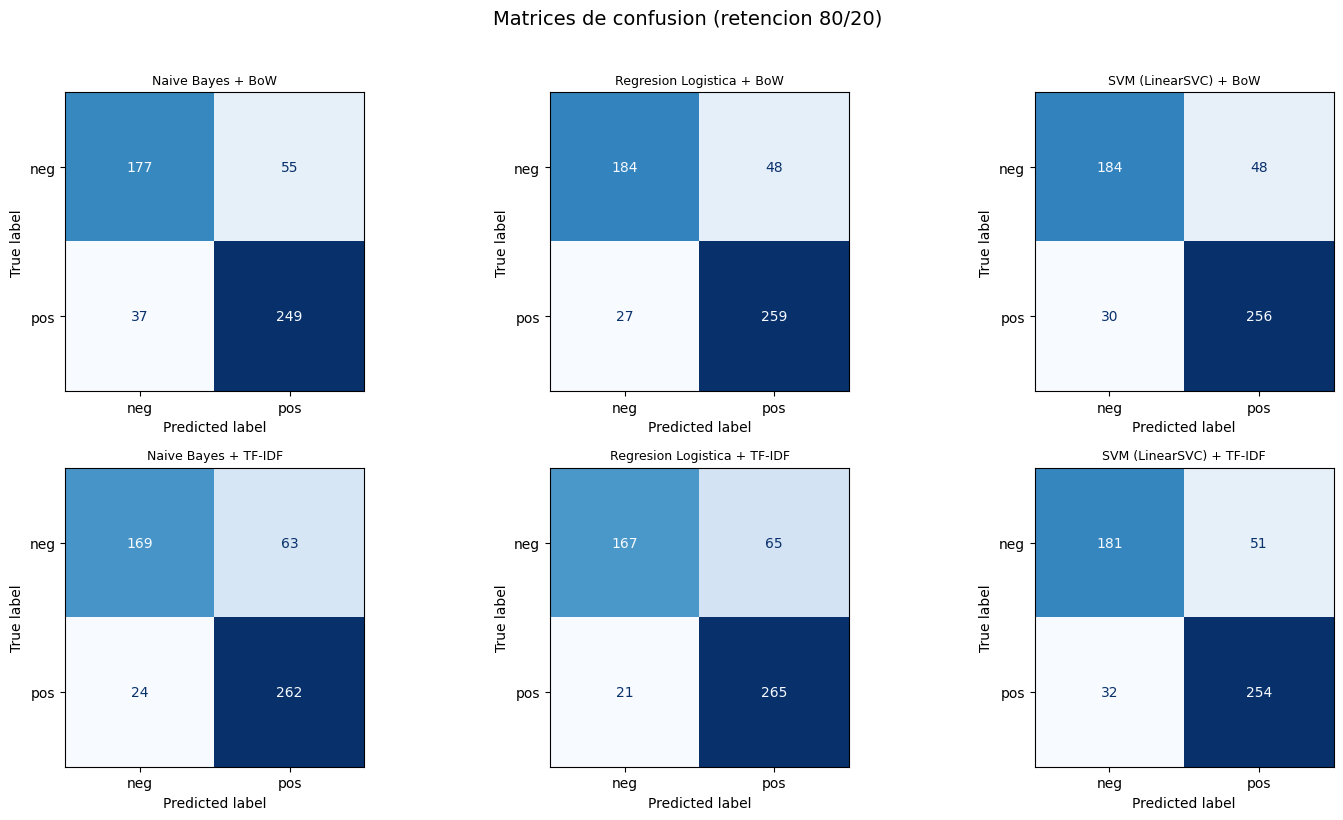

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Matrices de confusion (retencion 80/20)", fontsize=14, y=1.02)

for idx, (clave, res) in enumerate(resultados_holdout.items()):
    fila = idx // 3
    col = idx % 3
    ConfusionMatrixDisplay(res["cm"], display_labels=["neg", "pos"]).plot(ax=axes[fila][col], cmap="Blues", colorbar=False)
    axes[fila][col].set_title(clave, fontsize=9)

plt.tight_layout()
plt.show()

Analizando las matrices de confusión y las métricas obtenidas anteriormente, vemos que se observa un patrón común en todos los modelos, y es que el *recall* (sensibilidad) es sistemáticamente mayor en la clase positiva que en la negativa. Es decir, **los modelos identifican bien los textos positivos pero cometen más falsos positivos** (textos negativos clasificados como positivos). 

Esto es coherente con el ligero **desbalance del *dataset*** (55% positivos, 45% negativos), que hace que los modelos tiendan a predecir la clase mayoritaria. El caso más claro es Naive Bayes con TF-IDF, donde el *recall* de la clase negativa baja hasta 0.73 mientras que el de la clase positiva sube a 0.92, lo que muestra que este modelo en particular tiene más dificultad para captar las señales de negatividad cuando se usa TF-IDF. 

Si nos vamos a su matriz de confusión (**Naive Bayes + TF-IDF**) (la primera de la segunda fila), vemos que clasifica 63 textos negativos como positivos, pero solo falla en 24 positivos, lo que indica que tiende a sobrepredecir la clase positiva. **Regresión Logística con BoW** es el modelo más equilibrado en este sentido, con 48 falsos positivos frente a 27 falsos negativos. 

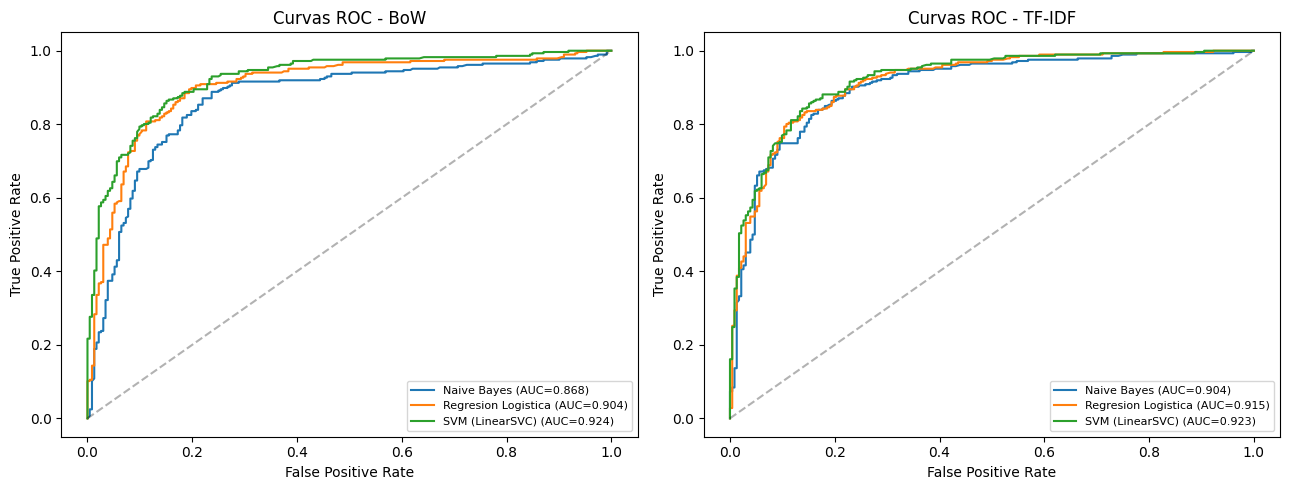

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for nombre_rep, ax in zip(["BoW", "TF-IDF"], axes):
    for nombre_modelo in modelos.keys():
        clave = f"{nombre_modelo} + {nombre_rep}"
        res = resultados_holdout[clave]
        ax.plot(res["fpr"], res["tpr"], label=f"{nombre_modelo} (AUC={res['auc']:.3f})")
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"Curvas ROC - {nombre_rep}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Por contextualizar, la curva ROC representa, para distintos umbrales de decisión, la relación entre la tasa de verdaderos positivos (eje Y) y la tasa de falsos positivos (eje X). Cuanto más se acerque la curva a la esquina superior izquierda, mejor discrimina el modelo. El AUC resume esa curva en un solo valor entre 0 y 1, donde 1 sería un clasificador perfecto y 0.5 equivaldría a decidir al azar (la diagonal discontinua).

En nuestro caso, las curvas ROC confirman lo observado en las métricas anteriores: SVM y Regresión Logística son los modelos más sólidos en ambas representaciones, y Naive Bayes se beneficia especialmente de TF-IDF, cerrando la brecha con los otros dos modelos. Esto se aprecia visualmente en que, con BoW, la curva de Naive Bayes queda ligeramente por debajo de las otras dos, mientras que con TF-IDF las tres curvas ascienden prácticamente juntas.

<a id='sec4_4'></a>
### 4.4. Tabla comparativa de resultados (retención)

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

print(f"{'Modelo':<35} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'AUC':<8}")
print("-" * 83)
for clave, res in resultados_holdout.items():
    prec = precision_score(y_test, res["y_pred"])
    rec = recall_score(y_test, res["y_pred"])
    f1 = f1_score(y_test, res["y_pred"])
    print(f"{clave:<35} {res['accuracy']:.4f}     {prec:.4f}     {rec:.4f}     {f1:.4f}     {res['auc']:.4f}")

Modelo                              Accuracy   Precision  Recall     F1-Score   AUC     
-----------------------------------------------------------------------------------
Naive Bayes + BoW                   0.8224     0.8191     0.8706     0.8441     0.8677
Regresion Logistica + BoW           0.8552     0.8436     0.9056     0.8735     0.9044
SVM (LinearSVC) + BoW               0.8494     0.8421     0.8951     0.8678     0.9239
Naive Bayes + TF-IDF                0.8320     0.8062     0.9161     0.8576     0.9044
Regresion Logistica + TF-IDF        0.8340     0.8030     0.9266     0.8604     0.9153
SVM (LinearSVC) + TF-IDF            0.8398     0.8328     0.8881     0.8596     0.9227


<a id='sec5'></a>
## 5. Evaluación mediante validación cruzada

La validación cruzada es más robusta que la retención simple porque evalúa el modelo sobre múltiples particiones del dataset, lo que nos da una visión más fiable de su rendimiento real y de su estabilidad.

<a id='sec5_1'></a>
### 5.1. Definición del esquema de validación cruzada

Utilizamos StratifiedKFold con k=10 particiones, que es el valor habitual. La estratificación garantiza que cada fold mantiene la proporción original de clases.

In [10]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score),
    'roc_auc': 'roc_auc',
}

print(f"Esquema: StratifiedKFold con k=10, shuffle=True, random_state=42")
print(f"Metricas evaluadas: accuracy, precision, recall, f1, roc_auc")

Esquema: StratifiedKFold con k=10, shuffle=True, random_state=42
Metricas evaluadas: accuracy, precision, recall, f1, roc_auc


<a id='sec5_2'></a>
### 5.2. Entrenamiento y evaluación por folds

Almacenamos las predicciones y probabilidades acumuladas en un diccionario para reutilizarlas directamente en las matrices de confusión y curvas ROC sin tener que reentrenar los modelos.

In [11]:
resultados_cv = {}
predicciones_cv = {}

datasets_cv = {
    "BoW": X_bow,
    "TF-IDF": X_tfidf,
}

scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score),
    'roc_auc': 'roc_auc',
}

# Evaluamos cada modelo con cada representacion usando cross-validation
# shuffle es como si barajeasemos el dataset antes de hacer los folds, para evitar que queden agrupados por clase o por orden de llegada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for nombre_rep, X_data in datasets_cv.items():
    print(f"\n{'='*60}")
    print(f"  Representacion: {nombre_rep}")
    print(f"{'='*60}")
    
    for nombre_modelo, modelo in modelos.items():
        clave = f"{nombre_modelo} + {nombre_rep}" # Creamos una clave para almacenar los resultados de este modelo y representación
        clf = clone(modelo)
        
        # Métricas por fold
        cv_res = cross_validate(clf, X_data, y, cv=cv, scoring=scoring)
        resultados_cv[clave] = cv_res
        
        # Predicciones acumuladas (para matrices de confusión y curvas ROC)
        clf2 = clone(modelo)
        y_pred_cv = cross_val_predict(clf2, X_data, y, cv=cv)
        clf3 = clone(modelo)
        y_prob_cv = cross_val_predict(clf3, X_data, y, cv=cv, method='predict_proba')[:, 1]
        predicciones_cv[clave] = {"y_pred": y_pred_cv, "y_prob": y_prob_cv}
        
        
        print(f"\n--- {nombre_modelo} ---")
        for metrica in ['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_roc_auc']:
            nombre_corto = metrica.replace('test_', '')
            valores = cv_res[metrica]
            print(f"  {nombre_corto:<12}: media={valores.mean():.4f}  std={valores.std():.4f}  (por fold: {np.round(valores, 4)})")


  Representacion: BoW

--- Naive Bayes ---
  accuracy    : media=0.8587  std=0.0224  (por fold: [0.8417 0.8842 0.8571 0.8803 0.8803 0.8803 0.834  0.8301 0.8726 0.8263])
  precision   : media=0.8612  std=0.0221  (por fold: [0.8592 0.8742 0.8487 0.8733 0.8836 0.8784 0.8425 0.8414 0.8929 0.8182])
  recall      : media=0.8874  std=0.0251  (por fold: [0.8531 0.9231 0.9021 0.9161 0.9021 0.9091 0.8601 0.8531 0.8741 0.8811])
  f1          : media=0.8739  std=0.0200  (por fold: [0.8561 0.898  0.8746 0.8942 0.8927 0.8935 0.8512 0.8472 0.8834 0.8485])
  roc_auc     : media=0.9007  std=0.0178  (por fold: [0.8909 0.9128 0.8965 0.9011 0.9067 0.9414 0.8689 0.905  0.8941 0.8897])

--- Regresion Logistica ---
  accuracy    : media=0.8873  std=0.0165  (por fold: [0.8803 0.888  0.8726 0.8919 0.9228 0.9073 0.8726 0.8919 0.8803 0.8649])
  precision   : media=0.8797  std=0.0268  (por fold: [0.8889 0.88   0.8526 0.8662 0.9489 0.894  0.8618 0.8758 0.8784 0.8506])
  recall      : media=0.9231  std=0.0165  (po

Los resultados confirman lo observado en retención: SVM es el modelo más sólido en ambas representaciones (accuracy de un 0.89, AUC de 0.94), seguido de Regresion Logística y Naive Bayes. Las desviaciones típicas son bajas en todos los casos, lo que indica que los modelos son estables entre folds.

<a id=sec5_3></a>
### 5.3. Presentación de resultados agregados

<a id='sec5_3_1'></a>
#### 5.3.1. Matrices de confusión acumuladas

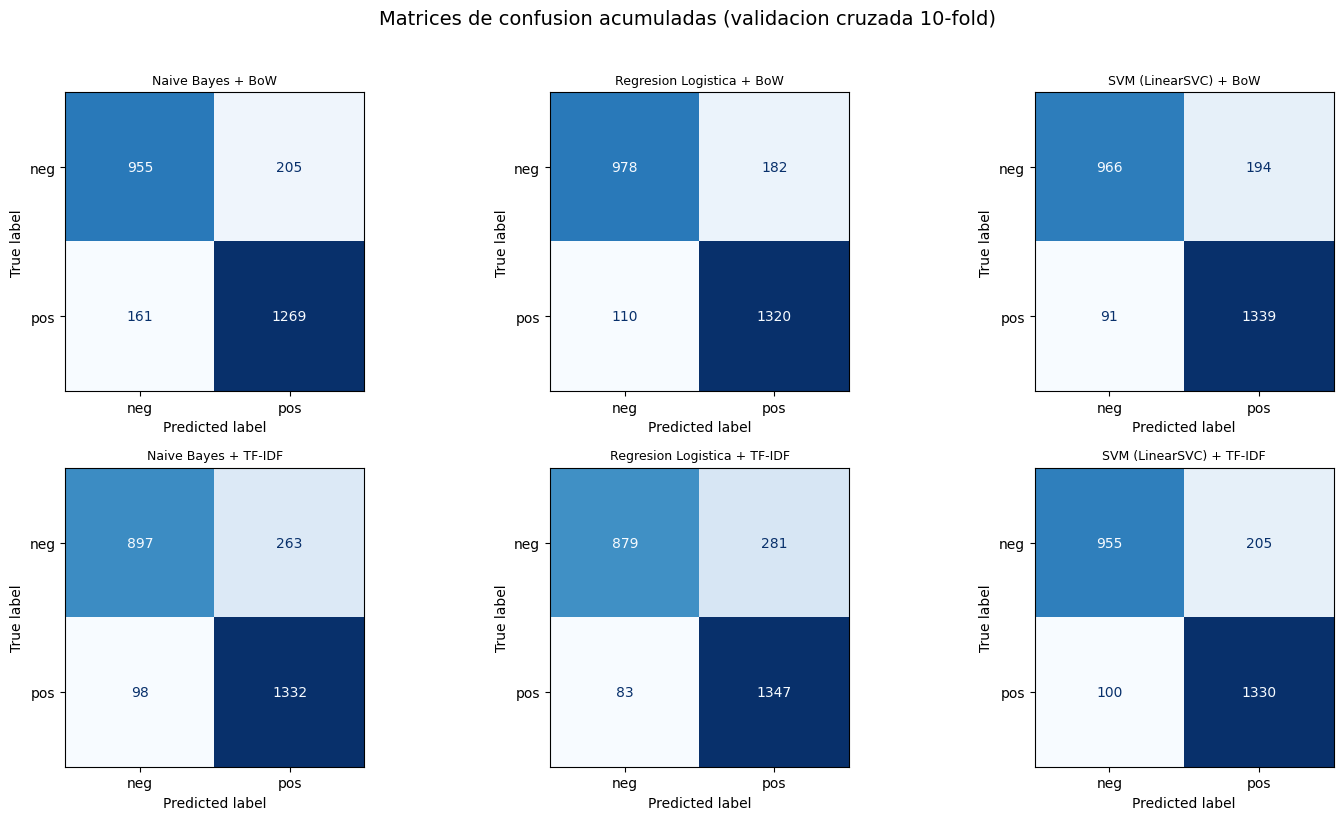

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Matrices de confusion acumuladas (validacion cruzada 10-fold)", fontsize=14, y=1.02)

for idx, (clave, preds) in enumerate(predicciones_cv.items()):
    cm_acum = confusion_matrix(y, preds["y_pred"])
    fila = idx // 3 # Para colocar cada matriz en la fila correspondiente (0 o 1)
    col = idx % 3 # Para colocar cada matriz en la columna correspondiente (0, 1 o 2)
    ConfusionMatrixDisplay(cm_acum, display_labels=["neg", "pos"]).plot(
        ax=axes[fila][col], cmap="Blues", colorbar=False
    )
    axes[fila][col].set_title(clave, fontsize=9)

plt.tight_layout()
plt.show()

Volvemos a ver el patrón visto en retención: más falsos positivos que falsos negativos en todos los modelos, y SVM con Bow pasa a ser el más equilibrado en ambos tipos de error.

#### 5.3.2. Curvas ROC acumuladas

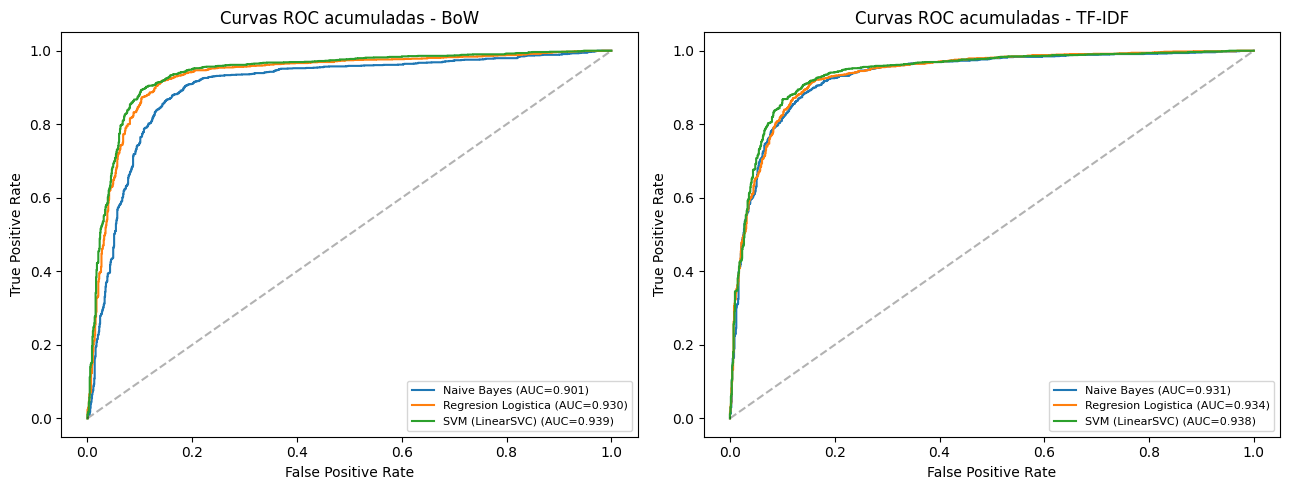

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, nombre_rep in zip(axes, ["BoW", "TF-IDF"]):
    for nombre_modelo in modelos.keys():
        clave = f"{nombre_modelo} + {nombre_rep}"
        preds = predicciones_cv[clave]
        fpr_cv, tpr_cv, _ = roc_curve(y, preds["y_prob"])
        roc_auc_cv = auc(fpr_cv, tpr_cv)
        ax.plot(fpr_cv, tpr_cv, label=f"{nombre_modelo} (AUC={roc_auc_cv:.3f})")
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"Curvas ROC acumuladas - {nombre_rep}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

De nuevo, el mismo patrón que en retención: con BoW, Naive Bayes queda por detrás, mientras que con TF-IDF, las tres curvas se igualan.

Aquí, **los AUCs acumulados son ligeramente superiores a los de retención**, lo cual es esperable al evaluar sobre todo el dataset mediante validación cruzada.

#### 5.3.3. Tabla resumen con media y desviación típica

In [14]:
print(f"{'Modelo':<35} {'Accuracy':<16} {'Precision':<16} {'Recall':<16} {'F1-Score':<16} {'AUC':<16}")
print("-" * 115)
for clave, cv_res in resultados_cv.items():
    acc_m, acc_s = cv_res['test_accuracy'].mean(), cv_res['test_accuracy'].std()
    pre_m, pre_s = cv_res['test_precision'].mean(), cv_res['test_precision'].std()
    rec_m, rec_s = cv_res['test_recall'].mean(), cv_res['test_recall'].std()
    f1_m, f1_s = cv_res['test_f1'].mean(), cv_res['test_f1'].std()
    auc_m, auc_s = cv_res['test_roc_auc'].mean(), cv_res['test_roc_auc'].std()
    print(f"{clave:<35} {acc_m:.4f}+-{acc_s:.4f}  {pre_m:.4f}+-{pre_s:.4f}  {rec_m:.4f}+-{rec_s:.4f}  {f1_m:.4f}+-{f1_s:.4f}  {auc_m:.4f}+-{auc_s:.4f}")

Modelo                              Accuracy         Precision        Recall           F1-Score         AUC             
-------------------------------------------------------------------------------------------------------------------
Naive Bayes + BoW                   0.8587+-0.0224  0.8612+-0.0221  0.8874+-0.0251  0.8739+-0.0200  0.9007+-0.0178
Regresion Logistica + BoW           0.8873+-0.0165  0.8797+-0.0268  0.9231+-0.0165  0.9005+-0.0138  0.9299+-0.0152
SVM (LinearSVC) + BoW               0.8900+-0.0144  0.8743+-0.0238  0.9364+-0.0229  0.9039+-0.0121  0.9403+-0.0113
Naive Bayes + TF-IDF                0.8606+-0.0177  0.8355+-0.0193  0.9315+-0.0218  0.8807+-0.0149  0.9307+-0.0137
Regresion Logistica + TF-IDF        0.8595+-0.0214  0.8279+-0.0227  0.9420+-0.0174  0.8811+-0.0173  0.9334+-0.0158
SVM (LinearSVC) + TF-IDF            0.8822+-0.0161  0.8672+-0.0232  0.9301+-0.0200  0.8972+-0.0135  0.9385+-0.0112


<a id='sec6'></a>
## 6. Discusión y análisis de resultados

### 6.1. Representación del texto y número de términos

La representación final utiliza 5000 términos con bigramas (1,2), min_df=2 y max_df=0.95. Como se ha mostrado en la sección de exploración de parámetros, usar solo unigramas reduce notablemente el vocabulario y pierde combinaciones relevantes para el sentimiento. También probamos min_df como porcentaje (0.01, 0.02 y 0.05), pero en un corpus de solo 2590 documentos, estos umbrales resultan demasiado restrictivos, llegando  a dejar el vocabulario en apenas 4 términos con min_df=0.05. 

El **límite de 5000 features** es un punto razonable: con más términos, el DTM se vuelve extremadamente disperso sin mejora apreciable, y con menos se pierden términos que, aunque poco frecuentes, pueden ser discriminativos.

El **parámetro max_df=0.95** descarta términos que aparecen en más del 95% de los documentos, ya que aportan poca capacidad discriminativa. El **min_df=2 elimina términos que solo aparecen en un documento, que suelen ser ruido** o incluso erratas.

En cuanto a la **decisión de eliminar *stopwords***, como se ha discutido en la sección de preprocesado, las pruebas realizadas confirman que es la opción que mejor rendimiento ofrece con esta configuración de vectorización. Al limitar el vocabulario a 5000 features, conservar *stopwords* haría que buena parte de ese espacio lo ocupasen términos sin carga sentimental, desplazando a los que realmente discriminan entre positivo y negativo.

### 6.2. Mejor resultado obtenido y comportamiento del modelo

In [15]:
print("Resumen de resultados en retención 80/20:\n")
mejor_clave = max(resultados_holdout, key=lambda k: resultados_holdout[k]['accuracy'])
mejor = resultados_holdout[mejor_clave]
print(f"Mejor modelo: {mejor_clave}")
print(f"Accuracy: {mejor['accuracy']:.4f}")
print(f"AUC: {mejor['auc']:.4f}")
print(f"\nMatriz de confusión:")
print(mejor['cm'])
print(f"\nReporte detallado:")
print(mejor['report'])

tn, fp, fn, tp = mejor['cm'].ravel()
print(f"El modelo comete {fp} falsos positivos (textos negativos clasificados como positivos)")
print(f"y {fn} falsos negativos (textos positivos clasificados como negativos).")

if fp > fn:
    print("Hay una tendencia a sobreclasificar como positivo, lo que puede deberse a que el corpus tiene más tweets positivos (55% vs 45%).")
elif fn > fp:
    print("Hay una tendencia mayor a falsos negativos, es decir, el modelo tiene algo más de dificultad para detectar correctamente los textos positivos.")
else:
    print("Los errores están equilibrados entre ambas clases.")

Resumen de resultados en retención 80/20:

Mejor modelo: Regresion Logistica + BoW
Accuracy: 0.8552
AUC: 0.9044

Matriz de confusión:
[[184  48]
 [ 27 259]]

Reporte detallado:
              precision    recall  f1-score   support

    negativo       0.87      0.79      0.83       232
    positivo       0.84      0.91      0.87       286

    accuracy                           0.86       518
   macro avg       0.86      0.85      0.85       518
weighted avg       0.86      0.86      0.85       518

El modelo comete 48 falsos positivos (textos negativos clasificados como positivos)
y 27 falsos negativos (textos positivos clasificados como negativos).
Hay una tendencia a sobreclasificar como positivo, lo que puede deberse a que el corpus tiene más tweets positivos (55% vs 45%).


### 6.3. Estabilidad y límite del rendimiento

In [16]:
print("Comparacion retencion 80/20 vs. validacion cruzada:\n")
print(f"{'Modelo':<35} {'Acc holdout':<14} {'Acc CV (media+-std)':<22}")
print("-" * 71)
for clave in resultados_holdout:
    acc_ho = resultados_holdout[clave]['accuracy']
    acc_cv_m = resultados_cv[clave]['test_accuracy'].mean()
    acc_cv_s = resultados_cv[clave]['test_accuracy'].std()
    print(f"{clave:<35} {acc_ho:.4f}        {acc_cv_m:.4f}+-{acc_cv_s:.4f}")

Comparacion retencion 80/20 vs. validacion cruzada:

Modelo                              Acc holdout    Acc CV (media+-std)   
-----------------------------------------------------------------------
Naive Bayes + BoW                   0.8224        0.8587+-0.0224
Regresion Logistica + BoW           0.8552        0.8873+-0.0165
SVM (LinearSVC) + BoW               0.8494        0.8900+-0.0144
Naive Bayes + TF-IDF                0.8320        0.8606+-0.0177
Regresion Logistica + TF-IDF        0.8340        0.8595+-0.0214
SVM (LinearSVC) + TF-IDF            0.8398        0.8822+-0.0161


Los resultados de validación cruzada son coherentes con los obtenidos en retención 80/20, con accuracies incluso ligeramente superiores en algunos casos (por ejemplo, SVM con BoW pasa de 0.849 en retención a 0.890 en CV). Las desviaciones típicas son reducidas (entre 0.01 y 0.02), lo que confirma que los modelos son estables y su rendimiento no depende de una partición concreta de los datos. **Podemos considerar los modelos fiables**.

**Sobre la posibilidad de alcanzar un 90% de accuracy** con estos datos, estamos cerca pero hay que ser realistas, ya que probablemente sea el techo con estas técnicas. Los tweets son textos cortos, con ambiguedad, ironía y errores ortograficos que dificultan la clasificación. Además, la representación BoW/TF-IDF pierde informacion contextual y de orden. Para superar este límite habría que explorar representaciones más sofisticadas como embeddings contextuales (BERT, por ejemplo). Con las herramientas clásicas que estamos utilizando, un accuracy en torno al 88-89% es un resultado bastante sólido para este tipo de corpus.

<a id='sec7'></a>
## 7. Bonus Track: Interpretabilidad del modelo mediante LIME

LIME (Local Interpretable Model-agnostic Explanations) nos permite entender, a nivel local, qué palabras están influyendo en la predicción del modelo para una instancia concreta. Esto es fundamental para validar que el modelo está tomando decisiones basadas en señales semanticas reales y no en artefactos del preprocesamiento.

In [17]:
from lime.lime_text import LimeTextExplainer
from sklearn.pipeline import make_pipeline

# Tomamos el mejor modelo de la validación cruzada
# Reentrenamos con el pipeline completo (vectorizador + clasificador)
# para que LIME pueda trabajar directamente sobre texto

mejor_cv_clave = max(resultados_cv, key=lambda k: resultados_cv[k]['test_accuracy'].mean())
print(f"Modelo seleccionado para LIME: {mejor_cv_clave}")
print(f"Accuracy CV media: {resultados_cv[mejor_cv_clave]['test_accuracy'].mean():.4f}")

# Identificamos que representación y modelo corresponden
if "TF-IDF" in mejor_cv_clave:
    from sklearn.feature_extraction.text import TfidfVectorizer
    vectorizer_lime = TfidfVectorizer(**vec_params)
else:
    # Aquí usamos CountVectorizer/TfidfVectorizer directamente en lugar de vectorizar_bow/vectorizar_tfidf
    # porque make_pipeline necesita un objeto transformador de scikit-learn que LIME pueda encadenar
    # con el clasificador para procesar texto crudo de forma integrada
    from sklearn.feature_extraction.text import CountVectorizer
    vectorizer_lime = CountVectorizer(**vec_params)

if "Naive Bayes" in mejor_cv_clave:
    clf_lime = MultinomialNB()
elif "Logística" in mejor_cv_clave:
    clf_lime = LogisticRegression(max_iter=1000, random_state=42)
else:
    clf_lime = CalibratedClassifierCV(LinearSVC(max_iter=5000, random_state=42))

pipeline_lime = make_pipeline(vectorizer_lime, clf_lime)
pipeline_lime.fit(lemas, y)

explainer = LimeTextExplainer(class_names=["negativo", "positivo"], random_state=42)
print("Pipeline y explainer LIME configurados correctamente.")

Modelo seleccionado para LIME: SVM (LinearSVC) + BoW
Accuracy CV media: 0.8900
Pipeline y explainer LIME configurados correctamente.


### 7.1. Selección de instancias para explicar

Seleccionamos 5 instancias del conjunto de test: dos correctamente clasificadas como positivas, dos como negativas, y una mal clasificada.

In [18]:
# Usamos la particion de test del holdout
_, lemas_test, _, _ = train_test_split(lemas, y, test_size=0.2, random_state=42, stratify=y)

y_pred_lime = pipeline_lime.predict(lemas_test)
y_prob_lime = pipeline_lime.predict_proba(lemas_test)

aciertos_pos = lemas_test[(y_pred_lime == 1) & (y_test == 1)]
aciertos_neg = lemas_test[(y_pred_lime == 0) & (y_test == 0)]
errores = lemas_test[y_pred_lime != y_test]

indices_explicar = []
indices_explicar.extend(aciertos_pos.index[:2].tolist())
indices_explicar.extend(aciertos_neg.index[:2].tolist())
indices_explicar.extend(errores.index[:1].tolist())

print(f"Instancias seleccionadas (indices): {indices_explicar}")
for i in indices_explicar:
    real = "positivo" if y_test.loc[i] == 1 else "negativo"
    pred = "positivo" if y_pred_lime[lemas_test.index.get_loc(i)] == 1 else "negativo"
    print(f"  idx={i}  real={real}  predicho={pred}  texto={lemas_test.loc[i][:80]}...")

Instancias seleccionadas (indices): [1835, 2501, 392, 676, 1143]
  idx=1835  real=positivo  predicho=positivo  texto=bravo medidor león clasificamos eliminar 3 pelear guaira cupo seguro realmente q...
  idx=2501  real=positivo  predicho=positivo  texto=atrevido yop...
  idx=392  real=negativo  predicho=negativo  texto=querer patín regalo frustrado...
  idx=676  real=negativo  predicho=negativo  texto=pqir distante wuieo4 matat...
  idx=1143  real=negativo  predicho=positivo  texto=creéi carrerir voltereta coche...


### 7.2. Explicaciones LIME


Instancia idx=1835 [ACIERTO] - Real: positivo, Predicho: positivo
P(negativo)=0.299, P(positivo)=0.701
Texto: bravo medidor león clasificamos eliminar 3 pelear guaira cupo seguro realmente quedar 1...

Terminos mas influyentes:
  seguro               peso=+0.1500  -> positivo
  realmente            peso=-0.0858  -> negativo
  bravo                peso=+0.0417  -> positivo
  pelear               peso=+0.0322  -> positivo
  eliminar             peso=-0.0285  -> negativo
  guaira               peso=+0.0233  -> positivo
  león                 peso=+0.0203  -> positivo
  quedar               peso=-0.0128  -> negativo
  clasificamos         peso=+0.0002  -> positivo
  3                    peso=-0.0001  -> negativo

Instancia idx=2501 [ACIERTO] - Real: positivo, Predicho: positivo
P(negativo)=0.300, P(positivo)=0.700
Texto: atrevido yop...

Terminos mas influyentes:
  atrevido             peso=+0.1021  -> positivo
  yop                  peso=-0.0359  -> negativo

Instancia idx=392 [ACIERTO] 

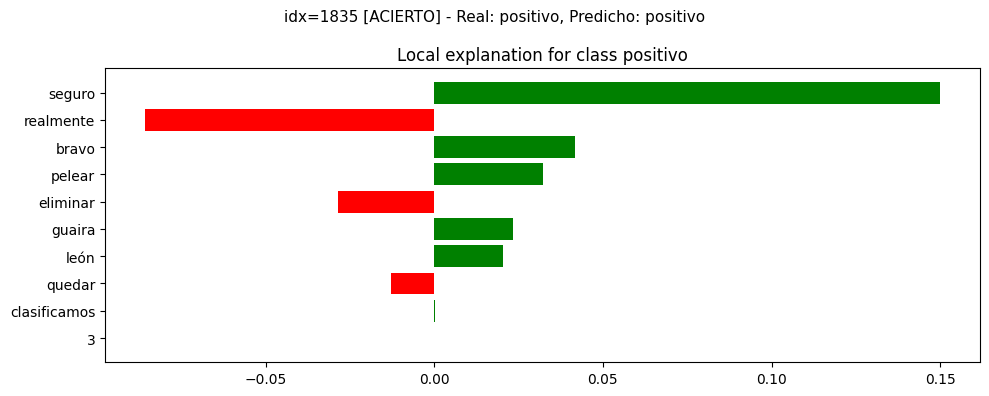

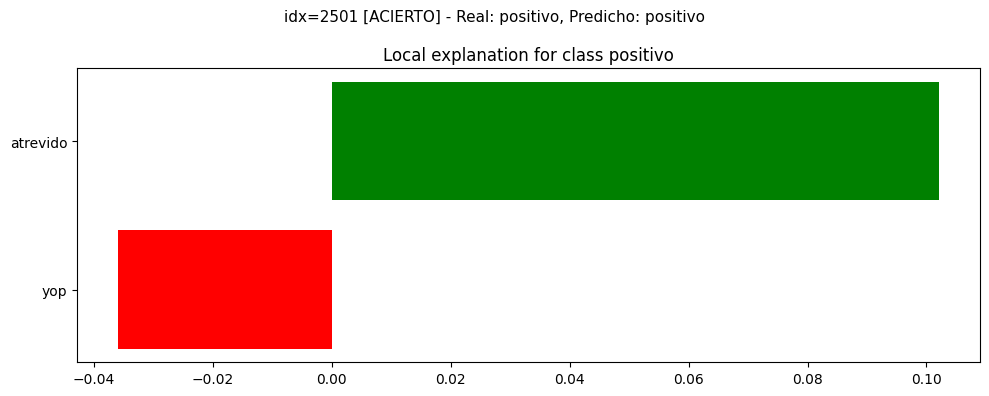

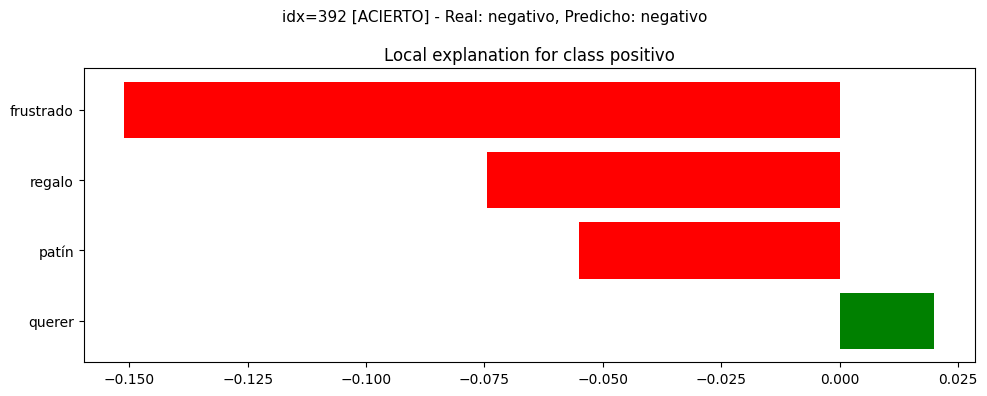

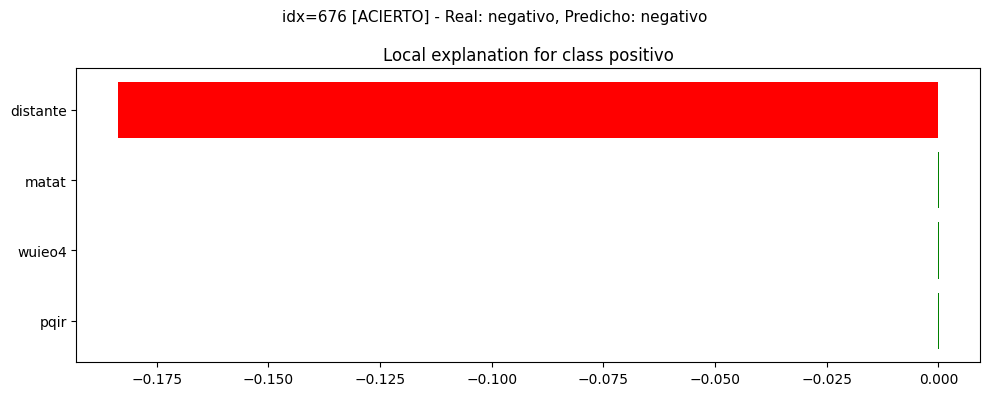

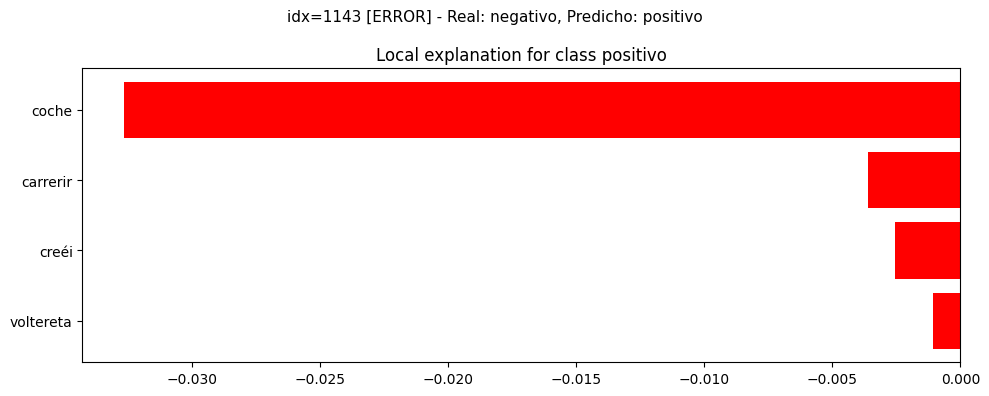

In [19]:
from IPython.display import display, HTML

figuras = []

for i in indices_explicar:
    texto = lemas_test.loc[i]
    real = "positivo" if y_test.loc[i] == 1 else "negativo"
    idx_local = lemas_test.index.get_loc(i)
    pred = "positivo" if y_pred_lime[idx_local] == 1 else "negativo"
    prob = y_prob_lime[idx_local]
    
    acierto = "ACIERTO" if real == pred else "ERROR"
    
    exp = explainer.explain_instance(texto, pipeline_lime.predict_proba, num_features=10)
    
    print(f"\n{'='*70}")
    print(f"Instancia idx={i} [{acierto}] - Real: {real}, Predicho: {pred}")
    print(f"P(negativo)={prob[0]:.3f}, P(positivo)={prob[1]:.3f}")
    print(f"Texto: {texto[:120]}...")
    
    print("\nTerminos mas influyentes:")
    for palabra, peso in exp.as_list():
        direccion = "-> positivo" if peso > 0 else "-> negativo"
        print(f"  {palabra:<20} peso={peso:+.4f}  {direccion}")
    
    fig = exp.as_pyplot_figure()
    fig.set_size_inches(10, 4)
    fig.suptitle(f"idx={i} [{acierto}] - Real: {real}, Predicho: {pred}", fontsize=11)
    fig.tight_layout()
    figuras.append(fig)
    plt.close(fig)

print(f"\n\n{'='*70}")
print("Visualizaciones LIME")
print(f"{'='*70}")
for fig in figuras:
    display(fig)

En las figuras de LIME, cada barra horizontal representa un término: las barras verdes empujan la predicción hacia positivo y las rojas hacia negativo. Cuanto más larga la barra, mayor es la influencia de ese término en la decisión del modelo.

- En la instancia 1835 (positivo, acierto), "seguro" es la palabra que más peso tiene hacia positivo, con diferencia. Aparecen también términos como "realmente" o "eliminar" empujando hacia negativo, pero no lo suficiente para contrarrestar la señal positiva.
- En la instancia 2501 (positivo, acierto), el texto es muy corto y "atrevido" domina claramente la predicción hacia positivo. "yop" tiene un peso negativo menor, probablemente por ser un término sin carga semántica real.
- En la instancia 392 (negativo, acierto), "frustrado" es el término más influyente, seguido de "regalo" y "patín", todos empujando hacia negativo. Solo "querer" aporta una señal positiva débil. Es un caso donde el modelo capta bien la semántica negativa.
- En la instancia 676 (negativo, acierto), "distante" domina la predicción con una barra roja larga. El resto de términos ("matat", "pqir", "wuieo4") son claramente ruido del preprocesado, con pesos prácticamente nulos, lo que indica que el modelo los ignora correctamente.
- En la instancia 1143 (negativo, error), el modelo predice positivo con poca confianza (P=0.522 vs 0.478). Todas las barras son rojas y cortas, lo que significa que ningún término aporta señal positiva clara. El modelo falla porque el texto contiene términos poco informativos ("carrerir", "creéi", "voltereta") que no tienen carga sentimental definida, y al no encontrar señales claras hacia ninguna clase, se inclina marginalmente hacia positivo por el sesgo del dataset que ya habíamos observado. Además, vemos como "coche" es el que más peso negativo tiene, y puede deberse a que el corpus haya tweets donde coche aparezca en contextos negativos (accidentes, por ejemplo).

<a id='sec7_3'></a>
### 7.3. Análisis crítico de las explicaciones LIME

A modo de conclusión, **las explicaciones LIME confirman que el modelo toma decisiones coherentes en la mayoríaa de los casos**: términos con carga emocional clara como "frustrado", "seguro" o "distante" son los que más pesan en las predicciones. Sin embargo, también hemos observado términos raros como "pqir" o "wuieo4" que, aunque en este caso tienen pesos despreciables, revelan que el preprocesado podría refinarse. 

El caso de error analizado (instancia 1143) ilustra una **limitación del modelo**: cuando el texto no contiene términos con carga sentimental definida, el clasificador carece de señales discriminativas y tiende a inclinarse hacia la clase mayoritaria.

Es importante recordar que LIME genera explicaciones locales, por lo que cada instancia tiene su propia interpretación y no se puede generalizar directamente a todo el modelo. Aun así, la consistencia observada a lo largo de las cinco instancias analizadas refuerza la confianza en que **el modelo está aprendiendo patrones linguísticos genuinos y no artefactos del preprocesamiento**.

<a id='sec8'></a>
## 8. Declaración de uso responsable de Inteligencia Artificial

En la elaboración de esta práctica, se ha utilizado la IA como herramienta de apoyo. Su uso se ha limitado a los siguientes aspectos:

- Mejora de la presentación visual de resultados y gráficas, incluyendo el formateo de tablas comparativas, la disposición de matrices de confusión y la configuración de curvas ROC.
- Corrección de errores puntuales de código, como problemas de compatibilidad entre librerias o ajustes sintácticos menores.
- Asistencia en la redacción de comentarios de código y textos explicativos partiendo siempre de las ideas y el análisis previo de los autores.

En ningún caso se ha delegado en la herramienta la toma de decisiones metodológicas, la elección de modelos o hiperparámetros, la interpretación de los resultados ni la elaboración de las conclusiones. Todo el criterio analítico, las reflexiones críticas y las valoraciones recogidas en este documento son responsabilidad exclusiva de los autores.